# Libs & Setup

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import logging
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import talib as ta
import math
from torch import optim
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from tqdm import tqdm
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch.optim import AdamW
from utils import inspect, inverse_transform, monte_carlo_statistic, calc_expected_returns, calc_covariance, calc_volatility
from utils.paths import CHECKPOINTS_DIR, REPORTS_SIM_DIR, RESULTS_DIR, REPORTS_QS_DIR
from pypfopt import risk_models, expected_returns, plotting, EfficientFrontier

import optuna
from optuna.trial import TrialState
import os
import random

# Own Libs
from config import *
from entities import *
from strategies import *
from datasets import *
from engine import Engine
from models import DiffusionTransformer, Diffusion

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# logging.basicConfig(level=logging.DEBUG)
logging.getLogger('matplotlib').setLevel(logging.WARNING)

## Random Seed

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # สำหรับ GPU
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(78)

In [4]:
# cfg = TrainConfig(epochs=2, window_size=64, device=torch.device("cuda:1"))


device = torch.device("cuda:0") # if torch.cuda.is_available() else "cpu")
batch_size = 64
batch_size_exp = 1
epochs = 1000

# Window
window_size = 30
stride = 1

# Simulation
steps_sim = 10
paths_sim = 1000

# Optimizer
lr: float = 1e-4
weight_decay: float = 0.01 # 1e-6
betas: tuple = (0.9, 0.999)
eps: float = 1e-8

# Optuna
n_trials = 100 
min_resource = 3
max_resource = 50
reduction_factor = 3
EPOCHS_PER_TRIAL = 50


# Model
ddpm = {
    'timesteps': 1000, # 50 - 200
    'beta_start': 0.00020095977802093984,
    'beta_end': 0.029157631381838023
}

ddpm_transformer = {
    'window_size': window_size,
    'd_model': 512,
    'nhead': 8,
    'num_layers': 3,
    'dim_feedforward': 1536,
    'dropout': 0.1
}


# Data
time_range = {
    'start_date': '2021-01-01',
    'end_date': '2024-12-31'
}

# Indicator & condition
time_prd = 20
day_shift = 1

# N channels
n_prices = 1
n_targets = 1
n_conditions = 12


ckpt_name = f"ddpm_transformer_d{ddpm_transformer['d_model']}_l{ddpm_transformer['num_layers']}"
checkpoint_dir = os.path.join(RESULTS_DIR,"experimental_checkpoints_norm_steps_h10_a6")
checkpoint_filename = f"tr{n_trials}_d{ddpm_transformer['d_model']}_dff{ddpm_transformer['dim_feedforward']}_l{ddpm_transformer['num_layers']}_h{ddpm_transformer['nhead']}_t{ddpm['timesteps']}.pt"

In [5]:
def time_range_info(df):
    info = (df.index.min(), df.index.max())
    print(f"Data range: {info[0]} to {info[1]}")
    
    duration = df.index.max() - df.index.min()
    print(f"Total duration: {duration}")

def time_range_mask(df, start_date, end_date):
    mask = (df.index >= start_date) & (df.index <= end_date)
    return mask

# Data

In [6]:
# symbols = ['AAPL', 'TSLA', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'GOOG', 'META', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'AMD', 'CSCO']
symbols = ['MSFT', 'NVDA', 'AMZN','ORCL', 'AMD', 'CSCO']
freq = "1d"

# Basket
basket = Basket(symbols=symbols)
basket.load_all_assets(freq=freq)

print(f"Basket data shape: {basket.data.shape}")
basket.data.head(5)

Basket data shape: (2760, 30)


MSFT                                                   NVDA  \
                Close       High        Low       Open      Volume     Close   
Date                                                                           
2015-01-02  39.933060  40.496700  39.745182  39.847661  27913900.0  0.483038   
2015-01-05  39.565842  39.907440  39.497520  39.599999  39673900.0  0.474880   
2015-01-06  38.985104  39.924502  38.891163  39.608523  36447900.0  0.460482   
2015-01-07  39.480434  39.676854  38.848476  39.266934  29114100.0  0.459282   
2015-01-08  40.641880  40.778520  39.898901  39.924520  29645200.0  0.476559   

                                                       ...   AMD              \
                High       Low      Open       Volume  ... Close  High   Low   
Date                                                   ...                     
2015-01-02  0.486638  0.475359  0.483038  113680000.0  ...  2.67  2.67  2.67   
2015-01-05  0.484478  0.472720  0.483038  197952000.0  ...  2.66  2.70  2.64   
2015-01-06  0.476080  0.460002  0.475600  197764000.0  ...  2.63  2.66  2.55   
2015-01-07  0.467921  0.457842  0.463841  321808000.0  ...  2.58  2.65  2.54   
2015-01-08  0.479439  0.464321  0.464561  283780000.0  ...  2.61  2.65  2.56   

                                   CSCO                                   \
            Open      Volume      Close       High        Low       Open   
Date                                                                       
2015-01-02  2.67         0.0  19.815605  20.181631  19.650534  19.995029   
2015-01-05  2.67   8878200.0  19.420874  19.700776  19.377812  19.607475   
2015-01-06  2.65  13912500.0  19.413698  19.865848  19.406522  19.478291   
2015-01-07  2.63  12377600.0  19.593126  19.664896  19.363463  19.478295   
2015-01-08  2.59  11136600.0  19.743843  20.160107  19.715135  19.765374   

                        
                Volume  
Date                    
2015-01-02  22926500.0  
2015-01-05  29460600.0  
2015-01-06  47297600.0  
2015-01-07  27570800.0  
2015-01-08  40907000.0  

[5 rows x 30 columns]

In [7]:
time_range_info(basket.data)

for symbol, asset in basket.assets.items():
    mask = time_range_mask(asset.data, time_range['start_date'], time_range['end_date'])
    asset.data = asset.data[mask]

time_range_info(basket.data)

Data range: 2015-01-02 00:00:00 to 2025-12-22 00:00:00
Total duration: 4007 days 00:00:00
Data range: 2021-01-04 00:00:00 to 2024-12-31 00:00:00
Total duration: 1457 days 00:00:00


In [8]:
targets = ["Close"]
features = basket.get_unique_features()
print(f"Features:\t{features}\nTargets:\t{targets}")

Features:	['Close', 'High', 'Low', 'Open', 'Volume']
Targets:	['Close']


In [9]:
df = basket.data
df.ffill(inplace=True)
df.head()

MSFT                                                \
                 Close        High         Low        Open    Volume   
Date                                                                   
2021-01-04  209.273178  214.377868  206.504526  213.926040  37130100   
2021-01-05  209.475021  210.071059  207.360086  208.859767  23823000   
2021-01-06  204.043503  208.119571  203.745491  203.966594  35930700   
2021-01-07  209.849976  210.859381  205.447071  205.764299  27694500   
2021-01-08  211.128555  212.051444  208.638699  210.224897  22956200   

                 NVDA                                              ...  \
                Close       High        Low       Open     Volume  ...   
Date                                                               ...   
2021-01-04  13.077455  13.614974  12.926870  13.068230  560640000  ...   
2021-01-05  13.367904  13.406547  13.051027  13.063742  322760000  ...   
2021-01-06  12.579825  13.208592  12.551404  13.186154  580424000  ...   
2021-01-07  13.307320  13.340977  12.851078  12.931854  461480000  ...   
2021-01-08  13.240254  13.384108  13.006150  13.325769  292528000  ...   

                  AMD                                                  CSCO  \
                Close       High        Low       Open    Volume      Close   
Date                                                                          
2021-01-04  92.300003  96.059998  90.919998  92.110001  51802600  38.239326   
2021-01-05  92.769997  93.209999  91.410004  92.099998  34208000  38.256729   
2021-01-06  90.330002  92.279999  89.459999  91.620003  51911700  38.622074   
2021-01-07  95.160004  95.510002  91.199997  91.330002  42897200  39.109196   
2021-01-08  94.580002  96.400002  93.269997  95.980003  39816400  39.196186   

                                                       
                 High        Low       Open    Volume  
Date                                                   
2021-01-04  38.595972  37.708707  38.543782  24392500  
2021-01-05  38.335017  37.734811  37.995770  17763700  
2021-01-06  39.030909  38.178440  38.387210  21823100  
2021-01-07  39.239677  38.422000  38.448099  18218800  
2021-01-08  39.500638  38.491593  38.691662  20936300  

[5 rows x 30 columns]

In [10]:
assets = df.columns.get_level_values(0).unique()
assets

Index(['MSFT', 'NVDA', 'AMZN', 'ORCL', 'AMD', 'CSCO'], dtype='object')

In [11]:
processed_dfs = []

for symbol in assets:
    asset_df = df.xs(symbol, level=0, axis=1).copy()

    close_price = asset_df['Close']
    volume = asset_df['Volume']
    high = asset_df['High']
    low = asset_df['Low']

    # =========================
    # 1. LOG RETURN (TARGET BASE)
    # =========================
    log_ret = np.log(close_price).diff()
    asset_df["Log_Returns Close"] = log_ret

    # =========================
    # 2. VOLUME STRUCTURE
    # =========================
    sma_volume = ta.SMA(volume, timeperiod=time_prd)
    asset_df["Norm_Volume"] = (
        (volume - sma_volume) / sma_volume
    ).shift(day_shift)

    asset_df["Vol_Shock"] = (
        volume / volume.rolling(time_prd).mean()
    ).shift(day_shift)

    # =========================
    # 3. PRICE DISTANCE
    # =========================
    sma_price = ta.SMA(close_price, timeperiod=time_prd)

    asset_df[f"Distance_SMA_{time_prd}"] = (
        (close_price - sma_price) / close_price
    ).shift(day_shift)

    # =========================
    # 4. REALIZED VOL
    # =========================
    asset_df[f"RV_{time_prd}"] = (
        np.sqrt((log_ret**2).rolling(time_prd).sum())
    ).shift(day_shift)

    # =========================
    # 5. CUMULATIVE RETURNS
    # =========================
    asset_df["CumRet_5"] = (
        np.log(close_price).diff(5)
    ).shift(day_shift)

    asset_df["CumRet_20"] = (
        np.log(close_price).diff(20)
    ).shift(day_shift)

    # =========================
    # 6. RANGE / VOL PROXY
    # =========================
    asset_df["HL_Range"] = (
        (high - low) / close_price
    ).shift(day_shift)

    asset_df[f"ATR_{time_prd}"] = (
        ta.ATR(high, low, close_price, timeperiod=time_prd)
    ).shift(day_shift)

    # =========================
    # 7. BOLLINGER POSITION
    # =========================
    std = close_price.rolling(time_prd).std()

    asset_df["BB_Position"] = (
        (close_price - sma_price) / (2 * std)
    ).shift(day_shift)

    # =========================
    # 8. SEMI VARIANCE
    # =========================
    downside = log_ret.copy()
    downside[downside > 0] = 0

    asset_df[f"SemiVar_{time_prd}"] = (
        np.sqrt((downside**2).rolling(time_prd).mean())
    ).shift(day_shift)

    # =========================
    # 9. VOL REGIME
    # =========================
    rv = asset_df[f"RV_{time_prd}"]

    asset_df["Vol_Regime"] = (
        rv > rv.rolling(60).mean()
    ).astype(int).shift(day_shift)

    # =========================
    # 10. ROLLING VWAP
    # =========================
    typical_price = (high + low + close_price) / 3
    rolling_tp_vol = (typical_price * volume).rolling(time_prd).sum()
    rolling_vol = volume.rolling(time_prd).sum()
    rolling_vwap = rolling_tp_vol / rolling_vol

    asset_df["Distance_Rolling_VWAP"] = (
        (close_price - rolling_vwap) / close_price
    ).shift(day_shift)

    # =========================
    # MultiIndex restore
    # =========================
    asset_df.columns = pd.MultiIndex.from_product([[symbol], asset_df.columns])
    processed_dfs.append(asset_df)

df_updated = pd.concat(processed_dfs, axis=1)
df_updated = df_updated.dropna()

In [12]:
nan_counts = df_updated.isna().sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [13]:
df_updated.dropna(inplace=True)
nan_counts = df_updated.isna().sum()
print(nan_counts[nan_counts > 0])
df_updated

Series([], dtype: int64)


MSFT                                                \
                 Close        High         Low        Open    Volume   
Date                                                                   
2021-02-03  233.604568  235.613757  230.009168  230.307194  27158100   
2021-02-04  232.652863  233.835316  231.076272  233.277740  25296100   
2021-02-05  232.835480  233.873724  231.124304  232.864319  18054800   
2021-02-08  233.095016  234.258224  231.499196  233.748718  22211900   
2021-02-09  234.344788  235.296500  232.047196  232.518241  23565000   
...                ...         ...         ...         ...       ...   
2024-12-24  436.929138  437.197682  431.817243  432.274721   7164500   
2024-12-26  435.715790  438.530341  434.243897  436.680490   8194200   
2024-12-27  428.177216  432.841588  424.020066  432.224981  18117700   
2024-12-30  422.508331  425.213468  419.594351  423.731620  13158700   
2024-12-31  419.196564  424.397993  418.361158  423.771431  13246500   

                                                                              \
           Log_Returns Close Norm_Volume Vol_Shock Distance_SMA_20     RV_20   
Date                                                                           
2021-02-03          0.014466   -0.226583  0.773417        0.064966  0.081569   
2021-02-04         -0.004082   -0.193538  0.806462        0.073230  0.082837   
2021-02-05          0.000785   -0.236779  0.763221        0.063291  0.078666   
2021-02-08          0.001114   -0.447221  0.552779        0.059090  0.073496   
2021-02-09          0.005347   -0.319168  0.680832        0.055425  0.073253   
...                      ...         ...       ...             ...       ...   
2024-12-24          0.009330   -0.177607  0.822393       -0.007066  0.056164   
2024-12-26         -0.002781   -0.678180  0.321820       -0.000051  0.056772   
2024-12-27         -0.017453   -0.618860  0.381140       -0.003991  0.052523   
2024-12-30         -0.013328   -0.156864  0.843136       -0.022543  0.054085   
2024-12-31         -0.007869   -0.383170  0.616830       -0.036424  0.055692   

            ...            CSCO                                          \
            ... Distance_SMA_20     RV_20  CumRet_5 CumRet_20  HL_Range   
Date        ...                                                           
2021-02-03  ...        0.014794  0.039737  0.012515  0.041659  0.011128   
2021-02-04  ...        0.011547  0.039756  0.001531  0.039894  0.013546   
2021-02-05  ...        0.039492  0.050029  0.041263  0.062213  0.032804   
2021-02-08  ...        0.052829  0.051469  0.075581  0.067093  0.017471   
2021-02-09  ...        0.065509  0.054392  0.075083  0.082600  0.015938   
...         ...             ...       ...       ...       ...       ...   
2024-12-24  ...        0.000907  0.035201  0.010739  0.007317  0.015259   
2024-12-26  ...        0.014503  0.037987  0.022473  0.018720  0.017544   
2024-12-27  ...        0.016314  0.035232  0.041705  0.006523  0.011004   
2024-12-30  ...        0.009940  0.035414  0.033780  0.005383  0.014763   
2024-12-31  ...        0.002931  0.036087  0.011384 -0.000338  0.016557   

                                                                              
              ATR_20 BB_Position SemiVar_20 Vol_Regime Distance_Rolling_VWAP  
Date                                                                          
2021-02-03  0.720684    0.743457   0.005339        0.0              0.014932  
2021-02-04  0.711616    0.688551   0.005347        0.0              0.011880  
2021-02-05  0.743450    1.700688   0.005347        0.0              0.040068  
2021-02-08  0.753685    1.577145   0.005347        0.0              0.052720  
2021-02-09  0.770802    1.460227   0.005347        0.0              0.064511  
...              ...         ...        ...        ...                   ...  
2024-12-24  0.847663    0.040218   0.005613        0.0              0.004061  
2024-12-26  0.856460    0.624991   0.005613    

In [14]:
drop_cols = ['Open', 'High', 'Low', 'Volume']

df_final = df_updated.drop(columns=drop_cols, level=1).copy()
df_final

MSFT                                          \
                 Close Log_Returns Close Norm_Volume Vol_Shock   
Date                                                             
2021-02-03  233.604568          0.014466   -0.226583  0.773417   
2021-02-04  232.652863         -0.004082   -0.193538  0.806462   
2021-02-05  232.835480          0.000785   -0.236779  0.763221   
2021-02-08  233.095016          0.001114   -0.447221  0.552779   
2021-02-09  234.344788          0.005347   -0.319168  0.680832   
...                ...               ...         ...       ...   
2024-12-24  436.929138          0.009330   -0.177607  0.822393   
2024-12-26  435.715790         -0.002781   -0.678180  0.321820   
2024-12-27  428.177216         -0.017453   -0.618860  0.381140   
2024-12-30  422.508331         -0.013328   -0.156864  0.843136   
2024-12-31  419.196564         -0.007869   -0.383170  0.616830   

                                                                              \
           Distance_SMA_20     RV_20  CumRet_5 CumRet_20  HL_Range    ATR_20   
Date                                                                           
2021-02-03        0.064966  0.081569  0.030436  0.095523  0.015114  5.344065   
2021-02-04        0.073230  0.082837  0.042452  0.109025  0.023992  5.357091   
2021-02-05        0.063291  0.078666  0.012809  0.131214  0.011859  5.227189   
2021-02-08        0.059090  0.073496  0.043199  0.103939  0.011808  5.103301   
2021-02-09        0.055425  0.073253  0.011698  0.098979  0.011836  4.986087   
...                    ...       ...       ...       ...       ...       ...   
2024-12-24       -0.007066  0.056164 -0.036854  0.042834  0.011074  8.058872   
2024-12-26       -0.000051  0.056772 -0.033859  0.047881  0.012314  7.924951   
2024-12-27       -0.003991  0.052523  0.001645  0.023370  0.009838  7.743025   
2024-12-30       -0.022543  0.054085 -0.014985  0.017669  0.020603  7.940660   
2024-12-31       -0.036424  0.055692 -0.027329  0.003230  0.013299  7.972770   

            ...            CSCO                                          \
            ... Distance_SMA_20     RV_20  CumRet_5 CumRet_20  HL_Range   
Date        ...                                                           
2021-02-03  ...        0.014794  0.039737  0.012515  0.041659  0.011128   
2021-02-04  ...        0.011547  0.039756  0.001531  0.039894  0.013546   
2021-02-05  ...        0.039492  0.050029  0.041263  0.062213  0.032804   
2021-02-08  ...        0.052829  0.051469  0.075581  0.067093  0.017471   
2021-02-09  ...        0.065509  0.054392  0.075083  0.082600  0.015938   
...         ...             ...       ...       ...       ...       ...   
2024-12-24  ...        0.000907  0.035201  0.010739  0.007317  0.015259   
2024-12-26  ...        0.014503  0.037987  0.022473  0.018720  0.017544   
2024-12-27  ...        0.016314  0.035232  0.041705  0.006523  0.011004   
2024-12-30  ...        0.009940  0.035414  0.033780  0.005383  0.014763   
2024-12-31  ...        0.002931  0.036087  0.011384 -0.000338  0.016557   

                                                                              
              ATR_20 BB_Position SemiVar_20 Vol_Regime Distance_Rolling_VWAP  
Date                                                                          
2021-02-03  0.720684    0.743457   0.005339        0.0              0.014932  
2021-02-04  0.711616    0.688551   0.005347        0.0              0.011880  
2021-02-05  0.743450    1.700688   0.005347        0.0              0.040068  
2021-02-08  0.753685    1.577145   0.005347        0.0              0.052720  
2021-02-09  0.770802    1.460227   0.005347        0.0              0.064511  
...              ...         ...        ...        ...                   ...  
2024-12-24  0.847663    0.040218   0.005613        0.0              0.004061  
2024-12-26  0.856460    0.624991   0.005613        0.0              0.018037  
2024-12-27  0.845808    0.681903   0.005613        0

In [15]:
close_price_df = df_final.xs('Close', level=1, axis=1)
close_price_df

,MSFT,NVDA,AMZN,ORCL,AMD,CSCO
Date,,,,,,
2021-02-03,233.604568,13.493309,165.626495,58.210693,87.889999,39.813793
2021-02-04,232.652863,13.626689,166.550003,59.315540,87.839996,41.101185
2021-02-05,232.835480,13.553641,167.607498,59.549629,87.900002,41.823177
2021-02-08,233.095016,14.399062,166.147003,59.090828,91.470001,42.571262
2021-02-09,234.344788,14.224045,165.250000,59.615166,90.910004,42.188519
...,...,...,...,...,...,...
2024-12-24,436.929138,140.189468,229.050003,169.721893,126.290001,58.345390
2024-12-26,435.715790,139.899521,227.050003,169.989227,125.059998,58.472118
2024-12-27,428.177216,136.980164,223.750000,167.296021,125.190002,58.111423


In [16]:
target_feature =  "Log_Returns Close"
def create_sequences(df, feature_name, steps: int):
    target_data = df.xs(feature_name, level=1, axis=1)

    sequence_list = []
    # such as steps = 8, loop 0 day to 7 day (include current date)
    for step in range(steps + 1):
        shifted_data = target_data.shift(-step)
        shifted_data.columns = [f"{col}_Day{step}" for col in shifted_data.columns]
        sequence_list.append(shifted_data)

    result_df = pd.concat(sequence_list, axis=1)
    result_df = result_df.sort_index(axis=1)
    return result_df

df_series_seq= create_sequences(df_final, target_feature, steps_sim)
df_series_seq

,AMD_Day0,AMD_Day1,AMD_Day10,AMD_Day2,AMD_Day3,AMD_Day4,AMD_Day5,AMD_Day6,AMD_Day7,AMD_Day8,...,ORCL_Day1,ORCL_Day10,ORCL_Day2,ORCL_Day3,ORCL_Day4,ORCL_Day5,ORCL_Day6,ORCL_Day7,ORCL_Day8,ORCL_Day9
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-03,-0.010976,-0.000569,-0.014560,0.000683,0.039811,-0.006141,0.015716,0.003351,0.011908,-0.024943,...,0.018802,-0.000322,0.003939,-0.007734,0.008834,-0.006302,-0.009050,0.006042,-0.015014,-0.000805
2021-02-04,-0.000569,0.000683,0.010549,0.039811,-0.006141,0.015716,0.003351,0.011908,-0.024943,-0.016759,...,0.003939,-0.015260,-0.007734,0.008834,-0.006302,-0.009050,0.006042,-0.015014,-0.000805,-0.000322
2021-02-05,0.000683,0.039811,-0.048137,-0.006141,0.015716,0.003351,0.011908,-0.024943,-0.016759,-0.014560,...,-0.007734,0.052887,0.008834,-0.006302,-0.009050,0.006042,-0.015014,-0.000805,-0.000322,-0.015260
2021-02-08,0.039811,-0.006141,-0.007407,0.015716,0.003351,0.011908,-0.024943,-0.016759,-0.014560,0.010549,...,0.008834,0.000776,-0.006302,-0.009050,0.006042,-0.015014,-0.000805,-0.000322,-0.015260,0.052887
2021-02-09,-0.006141,0.015716,0.025631,0.003351,0.011908,-0.024943,-0.016759,-0.014560,0.010549,-0.048137,...,-0.006302,0.003096,-0.009050,0.006042,-0.015014,-0.000805,-0.000322,-0.015260,0.052887,0.000776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.013472,-0.009787,NaN,0.001039,-0.022211,-0.013568,NaN,NaN,NaN,NaN,...,0.001574,NaN,-0.015970,-0.012207,-0.001619,NaN,NaN,NaN,NaN,NaN
2024-12-26,-0.009787,0.001039,NaN,-0.022211,-0.013568,NaN,NaN,NaN,NaN,NaN,...,-0.015970,NaN,-0.012207,-0.001619,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-27,0.001039,-0.022211,NaN,-0.013568,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.012207,NaN,-0.001619,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
new_columns = []
original_assets = df.columns.levels[0]

for col in df_series_seq.columns:
    for asset in original_assets:
        if col.startswith(asset):
            suffix = col.replace(asset, "") # "_Day+0", "_Day+1"
            new_feature_name = f"{target_feature}{suffix}"
            new_columns.append((asset, new_feature_name))
            break

# df_series_seq
multi_index_cols = pd.MultiIndex.from_tuples(new_columns, names=['Asset', 'Feature'])
df_series_seq.columns = multi_index_cols

df_final_updated = pd.concat([df_final, df_series_seq], axis=1)
df_final_updated = df_final_updated.sort_index(axis=1, level=0)

In [18]:
# df_final_updated['AAPL'].columns

In [19]:
target_drop_cols = ["Log_Returns Close"]
df_seq_final = df_final_updated.drop(columns=target_drop_cols, level=1).copy()

In [20]:
df_seq_final.dropna(inplace=True)
nan_counts = df_updated.isna().sum()
print(nan_counts[nan_counts > 0])
df_seq_final.shape

Series([], dtype: int64)


(974, 144)

In [21]:
import re

# 1. แยกกลุ่มคอลัมน์เหมือนเดิม
level_1_cols = df_seq_final.columns.get_level_values(1).unique().tolist()
first = ['Close']
others = [c for c in level_1_cols if c != 'Close' and 'Log_Returns' not in c]

# 2. จัดการกลุ่ม Log_Returns ด้วย Natural Sort
log_rets = [c for c in level_1_cols if 'Log_Returns' in c]

# ฟังก์ชันดึงตัวเลขจากชื่อคอลัมน์ (เช่น 'Day10' -> 10)
def extract_day_number(column_name):
    match = re.search(r'Day(\d+)', column_name)
    return int(match.group(1)) if match else 0

# เรียงลำดับตามตัวเลขที่สกัดได้
log_rets_sorted = sorted(log_rets, key=extract_day_number)

# 3. รวมลำดับใหม่และ reindex
new_level_1_order = first + others + log_rets_sorted
df_seq_final = df_seq_final.reindex(columns=new_level_1_order, level=1)
df_seq_final

AMD                                            \
                 Close    ATR_20 BB_Position CumRet_20  CumRet_5   
Date                                                               
2021-02-03   87.889999  3.648000   -0.382564 -0.037982 -0.063757   
2021-02-04   87.839996  3.572600   -0.485821 -0.054037 -0.010751   
2021-02-05   87.900002  3.470970   -0.463618 -0.027953  0.003650   
2021-02-08   91.470001  3.371422   -0.411356 -0.079360  0.026047   
2021-02-09   90.910004  3.407351    0.168495 -0.033435  0.042545   
...                ...       ...         ...       ...       ...   
2024-12-10  127.739998  4.896126   -1.185861 -0.122670 -0.082045   
2024-12-11  130.149994  4.875820   -1.350513 -0.142814 -0.105689   
2024-12-12  130.600006  4.881529   -0.912103 -0.098553 -0.101056   
2024-12-13  126.910004  4.799953   -0.755584 -0.064491 -0.079171   
2024-12-16  126.690002  4.886455   -0.984326 -0.089844 -0.088042   

                                                                        \
           Distance_Rolling_VWAP Distance_SMA_20  HL_Range Norm_Volume   
Date                                                                     
2021-02-03             -0.029528       -0.027521  0.026221   -0.337739   
2021-02-04             -0.039347       -0.036085  0.024349   -0.366637   
2021-02-05             -0.039095       -0.035257  0.017532   -0.383700   
2021-02-08             -0.035816       -0.030421  0.016837   -0.386411   
2021-02-09              0.006529        0.011496  0.043839   -0.041870   
...                          ...             ...       ...         ...   
2024-12-10             -0.063707       -0.064759  0.044090    0.818661   
2024-12-11             -0.081944       -0.083173  0.035150    0.222564   
2024-12-12             -0.054654       -0.057937  0.038340    0.405927   
2024-12-13             -0.046813       -0.050961  0.024885    0.058225   
2024-12-16             -0.069146       -0.076818  0.051454    0.976445   

                      ...                   ORCL                         \
               RV_20  ... Log_Returns Close_Day1 Log_Returns Close_Day2   
Date                  ...                                                 
2021-02-03  0.119231  ...               0.018802               0.003939   
2021-02-04  0.119627  ...               0.003939              -0.007734   
2021-02-05  0.116621  ...              -0.007734               0.008834   
2021-02-08  0.104344  ...               0.008834              -0.006302   
2021-02-09  0.111513  ...              -0.006302              -0.009050   
...              ...  ...                    ...                    ...   
2024-12-10  0.100625  ...               0.004715              -0.018424   
2024-12-11  0.103416  ...              -0.018424              -0.011069   
2024-12-12  0.101934  ...              -0.011069              -0.012536   
2024-12-13  0.097290  ...              -0.012536              -0.008916   
2024-12-16  0.101370  ...              -0.008916              -0.025664   

                                                          \
           Log_Returns Close_Day3 Log_Returns Close_Day4   
Date                                                       
2021-02-03              -0.007734               0.008834   
2021-02-04               0.008834              -0.006302   
2021-02-05              -0.006302              -0.009050   
2021-02-08              -0.009050               0.006042   
2021-02-09               0.006042              -0.015014   
...                           ...                    ...   
2024-12-10              -0.011069              -0.012536   
2024-12-11              -0.012536              -0.008916   
2024-12-12              -0.008916              -0.025664   
2024-12-13              -0.025664               0.020228   
2024-12-16               0.020228               0.005141   

                                                          \
           Log_Returns Close_Day5 Log_Returns Close_Day6   
Date             

In [22]:
# df_seq_final.xs("AAPL", level=0, axis=1).columns.unique()

In [23]:
# # type(df_final_updated)
# # df
# df_seq_final.xs("AAPL", level=0, axis=1).columns

# level_1_cols = df_seq_final.columns.get_level_values(1).unique().tolist()

# # 2. จัดกลุ่มตามเงื่อนไขเดิม
# first = ['Close']
# log_rets = [c for c in level_1_cols if 'Log_Returns' in c]
# others = [c for c in level_1_cols if c not in first and 'Log_Returns' not in c]

# # รวมลำดับที่ต้องการ: Close -> Others -> Log_Returns
# new_level_1_order = first + others + log_rets

# # 3. ใช้ reindex เพื่อจัดลำดับใหม่ในระดับ Level 1 สำหรับทุกหุ้น
# df_seq_final = df_seq_final.reindex(columns=new_level_1_order, level=1)
# df_seq_final

In [24]:
n_obs = len(df_seq_final)
n_assets = len(df_seq_final.columns.get_level_values(0).unique())
n_features = len(df_seq_final.columns.get_level_values(1).unique())

print(n_obs, n_assets, n_features)

974 6 24


In [25]:
market = df_seq_final.values.reshape(n_obs, n_assets, n_features)
print(type(market))
market.shape

# tensor_list = []
     #    for symbol in self.symbols:
     #        if symbol in self.assets:
     #            # Call Asset method
     #            asset_tensor = self.assets[symbol].to_tensor(features, device)
     #            tensor_list.append(asset_tensor)
        
     #    # Stack along dimension 1 (Dimension N)
     #    # Asset: [T, F] -> Stack dim=1 -> [T, A, F]
     #    basket_tensor = torch.stack(tensor_list, dim=1)

<class 'numpy.ndarray'>


(974, 6, 24)

In [26]:
df_seq_final.columns.remove_unused_levels()
df_seq_final.columns.get_level_values(1)

Index(['Close', 'ATR_20', 'BB_Position', 'CumRet_20', 'CumRet_5',
       'Distance_Rolling_VWAP', 'Distance_SMA_20', 'HL_Range', 'Norm_Volume',
       'RV_20',
       ...
       'Log_Returns Close_Day1', 'Log_Returns Close_Day2',
       'Log_Returns Close_Day3', 'Log_Returns Close_Day4',
       'Log_Returns Close_Day5', 'Log_Returns Close_Day6',
       'Log_Returns Close_Day7', 'Log_Returns Close_Day8',
       'Log_Returns Close_Day9', 'Log_Returns Close_Day10'],
      dtype='object', length=144)

In [27]:
# df_seq_final['AAPL'].columns

In [28]:
# market[0, 0, 0] # -> that close price 


print(f"Market shape:\t\t{market.shape}")
print(f"Close price:\t\t{market[:,:,0:1].shape}")
print(f"Features_Condition:\t{market[:,:,1:n_conditions + 1].shape}")
print(f"Features_Target:\t{market[:,:,n_conditions + 1:].shape}")

print(f"That's a close price:\t{market[0,0,0:1]}")
print(f"Feature_Cond values:\t{market[0, 0, 1:n_conditions + 1]}")
print(f"Feature Target values:\t{market[0, 0, n_conditions + 1:]}")

price = market[:, :, 0:1]
x     = market[:, :, n_conditions + 1:]
cond  = market[:, :, 1:n_conditions + 1]
date  = df_seq_final.index.get_level_values(0).unique().to_numpy()

# print(f"price shape: {price.shape}")
# print(f"x shape: {x.shape}")
# print(f"cond shape: {cond.shape}")
# print(f"date shape: {date.shape}")

Market shape:		(974, 6, 24)
Close price:		(974, 6, 1)
Features_Condition:	(974, 6, 12)
Features_Target:	(974, 6, 11)
That's a close price:	[87.88999939]
Feature_Cond values:	[ 3.64799995 -0.38256396 -0.03798207 -0.06375748 -0.02952836 -0.02752081
  0.02622104 -0.33773889  0.11923073  0.02049025  0.          0.66226111]
Feature Target values:	[-0.01097608 -0.00056909  0.00068289  0.03981124 -0.00614102  0.01571564
  0.00335123  0.01190802 -0.02494323 -0.0167589  -0.01455959]


In [29]:
def calc_ts_splits(total_samples, ratios, gap):
    total_gaps = gap * 2 # Actually there're 3 gap which one was cutted for NaN
    usable_pool = total_samples - total_gaps

    if usable_pool <= 0:
        return "Gap size more than avaliable data"

    train_count = math.floor(usable_pool * ratios[0])
    val_count = math.floor(usable_pool * ratios[1])
    test_count = usable_pool - train_count - val_count

    # -- Train --
    train_start = 0
    train_end = train_count

    # --- Gap 1 ---
    gap1_start = train_end
    gap1_end = gap1_start + gap

    # --- Val ---
    val_start = gap1_end
    val_end = val_start + val_count

    # --- Gap 2 ---
    gap2_start = val_end
    gap2_end = gap2_start + gap

    # --- Test ---
    test_start = gap2_end
    test_end = total_samples

    print(f"--- Configuration: Total {total_samples}, Gap {gap} ---")
    print(f"Train: [{train_start}:{train_end}]\t({train_count} samples)")
    print(f"Gap 1: [{gap1_start}:{gap1_end}]\t(DROPPED)")
    print(f"Val:   [{val_start}:{val_end}]\t({val_count} samples)")
    print(f"Gap 2: [{gap2_start}:{gap2_end}]\t(DROPPED)")
    print(f"Test:  [{test_start}:{test_end}]\t({test_count} samples)")
    
    return (train_start, train_end), (val_start, val_end), (test_start, test_end)

total_data = len(market)
ratios = [0.8, 0.1, 0.1]
gap = steps_sim

indices   = calc_ts_splits(total_data, ratios, gap)
all_dates = df_seq_final.index.get_level_values(0).unique().to_numpy()
all_prices = market[:, :, 0]

print(f"Dates shape: {all_dates.shape}")
print(f"Prices shape: {all_prices.shape}")
print(f"Market shape: {market.shape}")

--- Configuration: Total 974, Gap 10 ---
Train: [0:763]	(763 samples)
Gap 1: [763:773]	(DROPPED)
Val:   [773:868]	(95 samples)
Gap 2: [868:878]	(DROPPED)
Test:  [878:974]	(96 samples)
Dates shape: (974,)
Prices shape: (974, 6)
Market shape: (974, 6, 24)


In [30]:
(t_s, t_e), (v_s, v_e), (te_s, te_e) = indices

train_part = {
    "x": x[t_s:t_e],
    "cond": cond[t_s:t_e],
    "date": date[t_s:t_e],
    "price": price[t_s:t_e],
}

val_part = {
    "x": x[v_s:v_e],
    "cond": cond[v_s:v_e],
    "date": date[v_s:v_e],
    "price": price[v_s:v_e],
}

test_part = {
    "x": x[te_s:te_e],
    "cond": cond[te_s:te_e],
    "date": date[te_s:te_e],
    "price": price[te_s:te_e],
}

# 3. Print เช็คผล (จะเห็นว่า Total ของ X ทั้ง 3 ก้อน จะไม่เท่ากับ len(market) เพราะหัก Gap ไปแล้ว)
print(f"Train X: {train_part['x'].shape}\nVal X: {val_part['x'].shape}\nTest X: {test_part['x'].shape}")
print("-" * 30)
print(f"Train Cond: {train_part['cond'].shape}\nVal Cond: {val_part['cond'].shape}\nTest Cond: {test_part['cond'].shape}")
print("-" * 30)
print(f"Train Price: {train_part['price'].shape}\nVal Price: {val_part['price'].shape}\nTest Price: {test_part['price'].shape}")
print("-" * 30)
print(f"Train Dates: {train_part['date'].shape}\nVal Dates: {val_part['date'].shape}\nTest Dates: {test_part['date'].shape}")

Train X: (763, 6, 11)
Val X: (95, 6, 11)
Test X: (96, 6, 11)
------------------------------
Train Cond: (763, 6, 12)
Val Cond: (95, 6, 12)
Test Cond: (96, 6, 12)
------------------------------
Train Price: (763, 6, 1)
Val Price: (95, 6, 1)
Test Price: (96, 6, 1)
------------------------------
Train Dates: (763,)
Val Dates: (95,)
Test Dates: (96,)


In [31]:
# scaler_x = StandardScaler()
scaler_cond = StandardScaler()

# Scale X
# x_train_2d = train_part['x'].reshape(train_part['x'].shape[0], -1)
# x_val_2d = val_part['x'].reshape(val_part['x'].shape[0], -1)
# x_test_2d = test_part['x'].reshape(test_part['x'].shape[0], -1)

# scaler_x.fit(x_train_2d)

# train_x_scaled = scaler_x.transform(x_train_2d).reshape(train_part['x'].shape)
# val_x_scaled = scaler_x.transform(x_val_2d).reshape(val_part['x'].shape)
# test_x_scaled = scaler_x.transform(x_test_2d).reshape(test_part['x'].shape)

# inspect(train_x_scaled, "X_scaled - Train Part")
# inspect(val_x_scaled, "X_scaled - Val Part")
# inspect(test_x_scaled, "X_scaled - Test Part")

# Scale Cond
cond_train_2d = train_part['cond'].reshape(train_part['cond'].shape[0], -1)
cond_val_2d = val_part['cond'].reshape(val_part['cond'].shape[0], -1)
cond_test_2d = test_part['cond'].reshape(test_part['cond'].shape[0], -1)

scaler_cond.fit(cond_train_2d)

train_cond_scaled = scaler_cond.transform(cond_train_2d).reshape(train_part['cond'].shape)
val_cond_scaled = scaler_cond.transform(cond_val_2d).reshape(val_part['cond'].shape)
test_cond_scaled = scaler_cond.transform(cond_test_2d).reshape(test_part['cond'].shape)

inspect(train_cond_scaled, "Cond_scaled - Train Part")
inspect(val_cond_scaled, "Cond_scaled - Val Part")
inspect(test_cond_scaled, "Cond_scaled - Test Part")

# Pipeline([('Scaler_X', scaler_x), ('Scaler_Cond', scaler_cond)])

--- Inspecting: Cond_scaled - Train Part ---
------------------------------------
Shape: (763, 6, 12)
Min:   -5.4262
Max:   9.3562
Mean:  -0.0000
Std:   1.0000
------------------------------------
--- Inspecting: Cond_scaled - Val Part ---
------------------------------------
Shape: (95, 6, 12)
Min:   -2.4565
Max:   10.3928
Mean:  0.1054
Std:   1.2523
------------------------------------
--- Inspecting: Cond_scaled - Test Part ---
------------------------------------
Shape: (96, 6, 12)
Min:   -2.8358
Max:   15.3612
Mean:  0.2681
Std:   1.6987
------------------------------------


(np.float64(-2.8358427980497596),
 np.float64(15.361171311285926),
 np.float64(0.2680774863336915),
 np.float64(1.6987074521029513))

In [32]:

# train_ds = MarketDataset(x=train_x_scaled, cond=train_cond_scaled, date=train_part['date'], price=train_part['price'], window_size=window_size, stride=stride, normalize_window=True)
# val_ds = MarketDataset(x=val_x_scaled, cond=val_cond_scaled, date=val_part['date'], price=val_part['price'], window_size=window_size, stride=stride, normalize_window=True)
# test_ds = MarketDataset(x=test_x_scaled, cond=test_cond_scaled, date=test_part['date'], price=test_part['price'], window_size=window_size, stride=stride, normalize_window=True)


train_ds = MarketDataset(x=train_part['x'], cond=train_cond_scaled, date=train_part['date'], price=train_part['price'], window_size=window_size, stride=stride, normalize_window=True)
val_ds = MarketDataset(x=val_part['x'], cond=val_cond_scaled, date=val_part['date'], price=val_part['price'], window_size=window_size, stride=stride, normalize_window=True)
test_ds = MarketDataset(x=test_part['x'], cond=test_cond_scaled, date=test_part['date'], price=test_part['price'], window_size=window_size, stride=stride, normalize_window=True)

print(f"Num of Windows\nTrain DS: {len(train_ds)}, Val Ds: {len(val_ds)}, Test DS: {len(test_ds)}\n")
print(f"A sample shape from Train DS\n\tx: {train_ds[0]['x'].shape},\n\tcond: {train_ds[0]['cond'].shape}\n\tdates: {len(train_ds[0]['date'])}")

Num of Windows
Train DS: 734, Val Ds: 66, Test DS: 67

A sample shape from Train DS
	x: (11, 30, 6),
	cond: (12, 30, 6)
	dates: 30


In [33]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size_exp, shuffle=False)

batch_train = next(iter(train_loader))
print(len(train_loader))
print(batch_train["x"].shape)
print(batch_train["cond"].shape)
print(batch_train["x"][0,:,0,0])

12
torch.Size([64, 11, 30, 6])
torch.Size([64, 12, 30, 6])
tensor([-0.4391, -0.8145,  0.1662,  2.0147,  0.0394, -1.1381, -0.6252, -1.6345,
        -0.0668,  0.0582, -0.9324])


In [34]:
len(test_loader)

67

In [35]:
next(iter(test_loader))["x"].shape

torch.Size([1, 11, 30, 6])

In [36]:
batch_train["x"][0,:,0,0]
inv_batch_train_x= inverse_transform(batch_train["x"],batch_train["x_mean"], batch_train["x_std"])
inv_batch_train_x[0,:,0,0]

tensor([-0.0166, -0.0263,  0.0027,  0.0562, -0.0019, -0.0328, -0.0183, -0.0466,
        -0.0019,  0.0047, -0.0270])

In [37]:
B, C_cond, T, A = batch_train["cond"].shape
B, C_target, T, A = batch_train["x"].shape
print(f"B: {B}, C_target: {C_target}, C_cond: {C_cond}, T: {T}, A: {A}")

B: 64, C_target: 11, C_cond: 12, T: 30, A: 6


In [38]:

model = DiffusionTransformer(
    num_assets          = A,
    num_channels        = C_target,
    num_cond_channels   = C_cond,
    num_layers          = ddpm_transformer['num_layers'],
    num_attention_heads = ddpm_transformer['nhead'],
    seq_length          = T,
    d_model             = ddpm_transformer['d_model'],
    dim_feedforward     = ddpm_transformer['dim_feedforward'],
    dropout             = ddpm_transformer['dropout']
).to(device)

diffusion = Diffusion(
    model=model,
    timesteps=ddpm['timesteps'],
    beta_start=ddpm['beta_start'],
    beta_end=ddpm['beta_end']
).to(device)

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, cooldown=2, threshold=0.01)

engine = Engine(
    train_loader    = train_loader,
    val_loader      = val_loader,
    model           = diffusion,
    optimizer       = optimizer,
    criterion       = nn.MSELoss(),
    scheduler       = scheduler,
    device          = device,
    checkpoint_dir  = checkpoint_dir,
    checkpoint_filename = checkpoint_filename
)

checkpoint_dir = os.path.join(RESULTS_DIR,"experimental_checkpoints_no_norm")
checkpoint_filename = f"tr{n_trials}_d{ddpm_transformer['d_model']}_dff{ddpm_transformer['dim_feedforward']}_l{ddpm_transformer['num_layers']}_h{ddpm_transformer['nhead']}_t{ddpm['timesteps']}.pt"

input dim x: 66, d_model: 512


2026-02-16 09:27:13,840 - Engine - INFO - Engine initialized on cuda:0
2026-02-16 09:27:13,842 - Engine - INFO - Criterion: MSELoss


2026-02-16 09:27:13,858 - Engine - INFO - Starting training for 1000 epochs...
Train Ep 1: 100%|██████████| 12/12 [00:02<00:00,  4.74it/s, loss=0.9101]
2026-02-16 09:27:16,535 - Engine - INFO - Epoch 1 | Val Loss: 0.8803
2026-02-16 09:27:18,093 - Engine - INFO - New best model saved! (Val Loss: 0.8803)
Train Ep 2: 100%|██████████| 12/12 [00:01<00:00,  7.47it/s, loss=0.7964]
2026-02-16 09:27:19,784 - Engine - INFO - Epoch 2 | Val Loss: 0.7452
2026-02-16 09:27:20,792 - Engine - INFO - New best model saved! (Val Loss: 0.7452)
Train Ep 3: 100%|██████████| 12/12 [00:01<00:00,  7.94it/s, loss=0.5583]
2026-02-16 09:27:22,395 - Engine - INFO - Epoch 3 | Val Loss: 0.5411
2026-02-16 09:27:22,944 - Engine - INFO - New best model saved! (Val Loss: 0.5411)
Train Ep 4: 100%|██████████| 12/12 [00:01<00:00,  7.57it/s, loss=0.4039]
2026-02-16 09:27:24,589 - Engine - INFO - Epoch 4 | Val Loss: 0.5627
Train Ep 5: 100%|██████████| 12/12 [00:01<00:00, 10.09it/s, loss=0.3715]
2026-02-16 09:27:25,813 - Engin

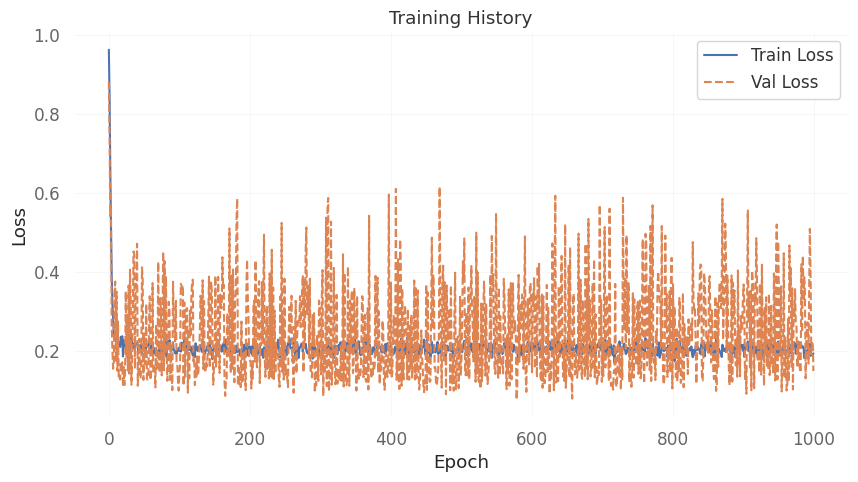

In [39]:
engine.fit(epochs)

# Experimental

In [40]:
batch_test = next(iter(test_loader))
print(f"x: {batch_test['x'].shape}, x_cond: {batch_test['cond'].shape}, dates: {batch_test['date'].shape}, prices: {batch_test['price'].shape}")

x: torch.Size([1, 11, 30, 6]), x_cond: torch.Size([1, 12, 30, 6]), dates: torch.Size([1, 30]), prices: torch.Size([1, 1, 30, 6])


In [41]:
def transform_dates(dates: torch.Tensor) -> pd.DatetimeIndex:
    dates_np = dates.cpu().numpy()
    dates_pd = pd.to_datetime(dates_np.flatten(), unit='ns')
    return dates_pd

In [42]:
engine.simulate('')

TypeError: Engine.simulate() missing 1 required positional argument: 'cond'

In [ ]:
engine.plot_history()

In [ ]:
12

In [ ]:
def plot_final_revised(real_data, mc_genai, mc_stat, asset_idx=0, context_window=2):
    # --- 1. Data Preparation (Anchoring Logic เหมือนเดิม) ---
    real_series = real_data[:, asset_idx].numpy()
    genai_series = mc_genai[:, :, asset_idx].numpy().T 
    stat_series = mc_stat[:, :, asset_idx].numpy().T
    
    total_len = len(real_series)
    sim_len = genai_series.shape[0]
    anchor_idx = total_len - sim_len - 1
    
    # เชื่อมจุด
    anchor_value = real_series[anchor_idx]
    anchor_row = np.full((1, genai_series.shape[1]), anchor_value)
    
    genai_plot = np.vstack([anchor_row, genai_series]) 
    stat_plot = np.vstack([anchor_row, stat_series])
    
    time_sim_extended = np.arange(anchor_idx, total_len)
    time_all = np.arange(total_len)
    start_plot_idx = max(0, anchor_idx - context_window + 1)

    # --- 2. Color & Style Setup ---
    plt.figure(figsize=(12, 6), dpi=120)
    
    # === COLORS PALETTE ===
    c_real = '#06C755'    # Vivid Green (ค่าเดิมที่คุณชอบ)
    
    # สีใหม่: ใช้โทนที่สว่างและ Clean ขึ้น (Material Colors)
    c_genai = '#FF5252'   # Red Accent (แดงสว่าง อมชมพูนิดๆ ดูไม่เก่า)
    c_stat = '#448AFF'    # Blue Accent (น้ำเงินฟ้า ดูเป็น Professional Stat)
    
    # สีเส้น Mean (ปรับให้เข้มกว่าตัวเส้นนิดหน่อย)
    c_genai_mean = '#D32F2F' 
    c_stat_mean = '#1976D2'

    # --- 3. Plotting Simulations (Thicker Lines) ---
    # linewidth=1.5 (หนาขึ้นอีก ตามขอ)
    # alpha=0.06 (ปรับลดลงนิดนึงเพราะเส้นหนาขึ้น เดี๋ยวทับกันแล้วทึบเกิน)
    
    # Stat Sim (Blue)
    plt.plot(time_sim_extended, stat_plot, color=c_stat, 
             linewidth=1.5, alpha=0.06, zorder=1)
    
    # GenAI Sim (Red)
    plt.plot(time_sim_extended, genai_plot, color=c_genai, 
             linewidth=1.5, alpha=0.06, zorder=2)

    # --- 4. Mean Lines (เส้นนำสายตา) ---
    plt.plot(time_sim_extended, np.mean(stat_plot, axis=1), color=c_stat_mean, 
             linewidth=2, linestyle='--', zorder=3, alpha=0.9)
             
    plt.plot(time_sim_extended, np.mean(genai_plot, axis=1), color=c_genai_mean, 
             linewidth=2, linestyle='--', zorder=4, alpha=0.9)

    # --- 5. Real Data (The Hero) ---
    # Halo Effect (ขอบขาว)
    plt.plot(time_all[start_plot_idx:], real_series[start_plot_idx:], 
             color='white', linewidth=4.5, zorder=5) # เพิ่มขอบขาวให้หนารับกับเส้นเขียว
             
    # Real Line
    plt.plot(time_all[start_plot_idx:], real_series[start_plot_idx:], 
             color=c_real, linewidth=2.5, marker='o', markersize=6, zorder=6)

    # --- 6. Decoration ---
    plt.axvline(x=anchor_idx, color='gray', linestyle=':', linewidth=1.5, alpha=0.4)
    
    plt.title(f'Asset {asset_idx} Forecast Analysis', fontsize=14, fontweight='bold', color='#333333', pad=15)
    plt.xlabel('Time Step', fontsize=11)
    plt.ylabel('Log Returns', fontsize=11)
    plt.xlim(start_plot_idx, total_len - 0.5)
    
    # Grid บางๆ สบายตา
    plt.grid(True, alpha=0.15, linestyle='--')
    
    # Legend
    custom_lines = [
        Line2D([0], [0], color=c_real, lw=2.5, marker='o', label='Ground Truth'),
        Line2D([0], [0], color=c_genai, lw=2, label='GenAI Model'),
        Line2D([0], [0], color=c_stat, lw=2, label='Statistical Model')
    ]
    plt.legend(handles=custom_lines, loc='upper left', frameon=True, 
               facecolor='white', framealpha=0.95, edgecolor='#E0E0E0')
    
    plt.tight_layout()
    plt.show()

In [ ]:
def expand_mc_size(x: torch.Tensor, cond: torch.Tensor, n_samples: int):
    return x.expand(n_samples, -1, -1, -1), cond.expand(n_samples, -1, -1, -1)

def transform_dates(dates: torch.Tensor, extend_days: int = 0) -> pd.DatetimeIndex:
    dates_np = dates.cpu().numpy()
    dates_pd = pd.to_datetime(dates_np.flatten(), unit='ns')


    extend_days: int = 0
    if extend_days > 0:
        last_date = dates_pd[-1]
        extended_range = pd.date_range(
            start=last_date + pd.Timedelta(days=1), 
            periods=extend_days, 
            freq='D'
        )
        dates_pd = dates_pd.append(extended_range)
        
    return dates_pd

n_samples = 1000


def evaluation(dataloader, num_samples_sim: int, rebalance_days: int = 1):
    count = 0
    
    eval_dir = os.path.join(REPORTS_QS_DIR, f"eval_{checkpoint_filename[:-3]}")
    os.makedirs(eval_dir, exist_ok=True)
    
    for batch in dataloader:
        # Monte Carlo
        # MC Genai
        x_mc, cond_mc = expand_mc_size(batch['x'], batch['cond'], num_samples_sim)
        print(f"x_mc: {x_mc.shape} , cond_mc: {cond_mc.shape}")

        # simulate with inpaiting
        sim_full_scaled, sim_only_scaled =  engine.simulate(x_mc.to(device), cond_mc.to(device))

        sim_only = inverse_transform(sim_full_scaled.to(device), batch['x_mean'].to(device), batch['x_std'].to(device))
        print(f"sim_only: {sim_only.shape}")
        

        mc_sim_genai = sim_only[:, 1:, -1:, :].squeeze(2)
        print(f"mc_sim_genai: {mc_sim_genai.shape}")

        steps_sim = mc_sim_genai.shape[1]
        print(f"steps_sim: {steps_sim}")
        
        # MC Stats
        x_unscaled = inverse_transform(batch['x'], batch['x_mean'], batch['x_std'])
        close_log_returns = x_unscaled[0, 0, :, :]
        print(f"Close log returns: {close_log_returns.shape}")

        mc_sim_stat = monte_carlo_statistic(torch.as_tensor(close_log_returns), n_sims=num_samples_sim, steps=steps_sim) # [n_sims, steps, assets]
        print(f"mc_sim_stat: {mc_sim_stat.shape}")

        # Ground truth
        gt = x_unscaled
        gt = gt[0, 1:, -1:, :]
        gt = gt.squeeze(1)
        print(f"gt: {gt.shape}")

        # Dates
        dates = transform_dates(batch['date'], steps_sim)[-steps_sim:]
        print(f"dates: {dates.shape}")
        
        # Portfolio management
        B_genai, F_genai, A_genai = mc_sim_genai.shape
        sim_genai_dist = mc_sim_genai.reshape(-1, A_genai) 
        
        B_stat, F_stat, A_stat = mc_sim_stat.shape
        sim_stat_dist = mc_sim_stat.reshape(-1, A_stat)

        risk_free_rate = 0.02/252
        weight_bounds = (0, 1)
        is_calc_distribution = True

        # New Dir per Batch contain sim
        # bt means batch test
        report_dir = os.path.join(eval_dir, f"bt{count}")
        os.makedirs(report_dir, exist_ok=True)
        
        for sim_idx in range(B_genai):
            sim_genai = mc_sim_genai[sim_idx, :, :]
            sim_stat  = mc_sim_stat[sim_idx, :, :]
            print(sim_genai.shape, sim_stat.shape)
            
            report_filename = f"sim{sim_idx}"
            portfolio = Portfolio(risk_free_rate, weight_bounds=weight_bounds, save_dir=report_dir)


            mu_genai, sigma_genai = portfolio.calc(sim_genai.cpu().numpy())
            mu_stats, sigma_stats = portfolio.calc(sim_stat.cpu().numpy())
            
            print(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
            print(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")
            # logger.debug(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
            # logger.debug(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")
        
            weights_genai = portfolio.optimize_weights(mu_genai, sigma_genai, risk_free_rate=risk_free_rate, scipy=True)
            weights_stats = portfolio.optimize_weights(mu_stats, sigma_stats, risk_free_rate=risk_free_rate, scipy=True)
        
            print(f"weights_genai: {weights_genai.shape}")
            print(f"weights_stats: {weights_stats.shape}")
            
            # logger.debug(f"weights_genai: {weights_genai.shape}")
            # logger.debug(f"weights_stats: {weights_stats.shape}")
    
            report = portfolio.back_test(weights=weights_genai, weights_benchmark=weights_stats, returns=gt.cpu().numpy(), dates=dates, is_saved=True, filename=report_filename, rebalance_days=rebalance_days)

        logs_filename = os.path.join(report_dir, f"logs_data.pt")
        torch.save({
            "x_unscaled": x_unscaled,
            "dates": dates,
            "mc_sim_genai": mc_sim_genai,
            "mc_sim_stat": mc_sim_stat,
            "gt": gt
        }, logs_filename)

        # plot_final_revised(real_data, mc_genai, mc_stat, asset_idx=0, context_window=2)
        
        count += 1
        break

In [ ]:
evaluation(test_loader, 1000)

In [ ]:
fig1 = plot_param_importances(study)
fig1.show(renderer="notebook")

# 2. ดูแนวโน้มว่า Loss ลดลงเรื่อยๆ ไหม
fig2 = plot_optimization_history(study)
fig2.show(renderer="notebook")

In [ ]:
best_params = study.best_params
best_params

# Experimental

In [ ]:
def extract_simulation_stats(sim_data: np.ndarray, method: str = 'separate'):
    """
    สกัดค่า Mu และ Sigma จากข้อมูล Simulation หลายเส้นทาง
    
    Parameters:
    - sim_data: numpy array รูปแบบ [N_sims, Steps, Assets] (เช่น 1000, 20, 5)
    - method: 'combined' (เทรวมกัน) หรือ 'separate' (คิดแยกทีละเส้นทางแล้วเฉลี่ย)
    
    Returns:
    - mu_final: numpy array รูปแบบ [Assets,]
    - sigma_final: numpy array รูปแบบ [Assets, Assets]
    """
    N_sims, Steps, Assets = sim_data.shape

    if method == 'combined':
        # วิธีที่ 1: รวมทุกเส้นทางเป็น Distribution เดียว
        flattened_data = sim_data.reshape(-1, Assets) 
        mu_final = calc_expected_returns(flattened_data)
        sigma_final = calc_covariance(flattened_data)
        
    elif method == 'separate':
        # วิธีที่ 2: คิดแยกทีละเส้นทาง (Path-by-Path)
        mu_list = []
        sigma_list = []
        
        for i in range(N_sims):
            path_data = sim_data[i, :, :] # ดึงมาทีละ 1 เส้นทาง
            
            # เรียกใช้ฟังก์ชันย่อย
            mu_path = calc_expected_returns(path_data)
            sigma_path = calc_covariance(path_data)
            
            mu_list.append(mu_path)
            sigma_list.append(sigma_path)
            
        # นำค่าสถิติของทั้ง 1,000 เส้นทางมาหาค่าเฉลี่ย
        mu_final = np.mean(mu_list, axis=0)
        sigma_final = np.mean(sigma_list, axis=0)
        
    else:
        raise ValueError("Parameter 'method' ต้องเป็น 'combined' หรือ 'separate' เท่านั้น")

    return mu_final, sigma_final

In [ ]:
from scipy.stats import skew, kurtosis

def get_generation_level_stats(data: np.ndarray, model_name: str, is_gt: bool = False) -> pd.DataFrame:
    """
    ดึงค่าสถิติ Model Performance ระดับ Generation Level
    
    Parameters:
    - data: หากเป็น GenAI/Stat จะเป็น shape [N_paths, Steps, Assets]
            หากเป็น Ground Truth (GT) จะเป็น shape [Steps, Assets]
    - model_name: ชื่อโมเดล เช่น 'GenAI', 'GBM-Stat', 'Ground-Truth'
    - is_gt: Flag ระบุว่าเป็น Ground Truth หรือไม่
    
    Returns:
    - pd.DataFrame สรุปค่าสถิติของแต่ละ Asset
    """
    # ถ้าเป็นข้อมูลจำลอง (มี N_paths) เราจะรวบทุกเส้นทางมาดู Distribution รวม
    if not is_gt and len(data.shape) == 3:
        N_paths, Steps, Assets = data.shape
        data_flat = data.reshape(-1, Assets) # รวมเป็น [N_paths * Steps, Assets]
    else:
        # ถ้าเป็น GT จะมีแค่ 2 มิติ [Steps, Assets] อยู่แล้ว
        Assets = data.shape[-1]
        data_flat = data

    stats_list = []
    
    # คำนวณสถิติทีละ Asset
    for asset_idx in range(Assets):
        asset_data = data_flat[:, asset_idx]
        
        stats = {
            'Model': model_name,
            'Asset_Idx': asset_idx,
            'Mean': np.mean(asset_data),
            'Std (Volatility)': np.std(asset_data),
            'Min': np.min(asset_data),
            'Max': np.max(asset_data),
            'Skewness': skew(asset_data),      # ความเบ้ (ดูว่าผลตอบแทนเอียงไปทางบวกหรือลบ)
            'Kurtosis': kurtosis(asset_data)   # ความโด่ง (ดูความเสี่ยงของหาง (Fat-tail risk))
        }
        stats_list.append(stats)
        
    return pd.DataFrame(stats_list)

In [ ]:
def evaluation(dataloader, engine, num_samples_sim: int = 1000, is_dynamic: bool = False, rebalance_freq: int = 5):
    """
    is_dynamic: หากเป็น False คือ Static (จัดครั้งเดียว) | หากเป็น True คือจัดพอร์ตแบบ Rolling
    rebalance_freq: จำนวนวันที่จะถือพอร์ตก่อนทำการจำลองและ Optimize ใหม่ (ใช้เมื่อ is_dynamic=True)
    """
    eval_dir = os.path.join(REPORTS_QS_DIR, f"eval_{checkpoint_filename[:-3]}")
    os.makedirs(eval_dir, exist_ok=True)
    
    count = 0
    
    for batch in dataloader:
        print(f"\n{'='*40}\n🚀 ประมวลผล Batch ที่ {count}\n{'='*40}")
        
        # -----------------------------------------------------
        # 1. GENERATION LEVEL: จำลองข้อมูล
        # -----------------------------------------------------
        # GenAI Simulation
        x_mc, cond_mc = expand_mc_size(batch['x'], batch['cond'], num_samples_sim)
        sim_full_scaled, sim_only_scaled = engine.simulate(x_mc.to(device), cond_mc.to(device))
        sim_only = inverse_transform(sim_full_scaled.to(device), batch['x_mean'].to(device), batch['x_std'].to(device))
        mc_sim_genai = sim_only[:, 1:, -1:, :].squeeze(2) # [1000, Steps, Assets]
        
        # Stat Simulation (GBM)
        x_unscaled = inverse_transform(batch['x'], batch['x_mean'], batch['x_std'])
        close_log_returns = x_unscaled[0, 0, :, :] 
        steps_sim = mc_sim_genai.shape[1]
        mc_sim_stat = monte_carlo_statistic(torch.as_tensor(close_log_returns), n_sims=num_samples_sim, steps=steps_sim)
        
        # Ground Truth
        gt = x_unscaled[0, 1:, -1:, :].squeeze(1) # [Steps, Assets]
        dates = transform_dates(batch['date'], steps_sim)[-steps_sim:]

        # -----------------------------------------------------
        # 2. MODEL PERFORMANCE: ดึงตารางสถิติ (ตาม Workflow ของคุณ)
        # -----------------------------------------------------
        sim_genai_np = mc_sim_genai.detach().cpu().numpy()
        sim_stat_np = mc_sim_stat.detach().cpu().numpy()
        gt_np = gt.detach().cpu().numpy()

        df_stats_genai = get_generation_level_stats(sim_genai_np, model_name="GenAI")
        df_stats_stat  = get_generation_level_stats(sim_stat_np, model_name="GBM-Stat")
        df_stats_gt    = get_generation_level_stats(gt_np, model_name="GroundTruth", is_gt=True)
        
        # รวมตารางสถิติเพื่อดูเปรียบเทียบ
        df_performance = pd.concat([df_stats_gt, df_stats_stat, df_stats_genai], ignore_index=True)
        print("\n📊 Model Performance (Generation Level):")
        print(df_performance.to_string())
        # สามารถเซฟ df_performance ลง .csv ได้ตรงนี้

        # -----------------------------------------------------
        # 3. PORTFOLIO OPTIMIZATION & BACKTEST
        # -----------------------------------------------------
        risk_free_rate = 0.02 / 252
        weight_bounds = (0, 1)
        report_dir = os.path.join(eval_dir, f"bt{count}")
        os.makedirs(report_dir, exist_ok=True)
        portfolio = Portfolio(risk_free_rate, weight_bounds=weight_bounds, save_dir=report_dir)

        if not is_dynamic:
            # === แบบที่ 1: STATIC PORTFOLIO (ทำเหมือนเดิมที่คุณมี) ===
            print("\n📈 โหมด: Static Portfolio (Buy & Hold)")
            # 1. สกัดค่า Mu, Sigma รวม
            mu_genai, sigma_genai = extract_simulation_stats(sim_genai_np, method='separate')
            mu_stats, sigma_stats = extract_simulation_stats(sim_stat_np, method='separate')
            
            # 2. Optimize Weights ครั้งเดียวสำหรับหน้าต่างเวลานี้
            weights_genai = portfolio.optimize_weights(mu_genai, sigma_genai, risk_free_rate=risk_free_rate, scipy=True)
            weights_stats = portfolio.optimize_weights(mu_stats, sigma_stats, risk_free_rate=risk_free_rate, scipy=True)
            
            # 3. Backtest ผลลัพธ์รวดเดียว
            report_filename = f"static_comparison_report"
            report = portfolio.back_test(
                weights=weights_genai, weights_benchmark=weights_stats, 
                returns=gt_np, dates=dates, is_saved=True, 
                filename=report_filename, rebalance_days=1 # 1 คือคิดผลตอบแทนรายวัน แต่ไม่ได้เปลี่ยนน้ำหนัก
            )
            
        else:
            # === แบบที่ 2: DYNAMIC PORTFOLIO (โครงสร้างการทำ Rolling Rebalance) ===
            print(f"\n🔄 โหมด: Dynamic Portfolio (Rebalance ทุกๆ {rebalance_freq} วัน)")
            """
            แนวคิดสำหรับการทำ Dynamic:
            ในโลกความจริงเราจะไม่รู้ GT ทั้งเส้น เราจึงต้องซอย Loop ย่อยตาม rebalance_freq
            """
            portfolio_returns_genai = []
            portfolio_returns_stats = []
            
            # สมมติว่า steps_sim = 20, rebalance_freq = 5
            for start_idx in range(0, steps_sim, rebalance_freq):
                end_idx = min(start_idx + rebalance_freq, steps_sim)
                
                # ข้อควรระวัง: ในการทำ Dynamic ที่แท้จริง ตรงนี้คุณต้องดึง "บริบทของตลาด ณ วันที่ start_idx"
                # มาเข้าโมเดล GenAI/Stat ใหม่ เพื่อจำลองอนาคตระยะสั้นของลูปนี้ 
                # (แต่ในโค้ดนี้เราดึงจากก้อนใหญ่ที่จำลองไว้แล้วมาหั่นเป็นช่วงๆ เพื่อแสดงแนวคิดก่อน)
                
                current_sim_genai = sim_genai_np[:, start_idx:end_idx, :]
                current_sim_stat  = sim_stat_np[:, start_idx:end_idx, :]
                current_gt        = gt_np[start_idx:end_idx, :]
                
                # 1. ดึงสถิติของช่วงเวลานี้
                mu_g, cov_g = extract_simulation_stats(current_sim_genai, method='separate')
                mu_s, cov_s = extract_simulation_stats(current_sim_stat, method='separate')
                
                # 2. หา Weights ใหม่ (Rebalance)
                w_g = portfolio.optimize_weights(mu_g, cov_g, risk_free_rate=risk_free_rate, scipy=True)
                w_s = portfolio.optimize_weights(mu_s, cov_s, risk_free_rate=risk_free_rate, scipy=True)
                
                # 3. คำนวณผลตอบแทนของพอร์ตในช่วงเวลานี้ (นำน้ำหนักไปคูณกับผลตอบแทนจริง GT)
                # w_g shape: (Assets,) | current_gt shape: (Freq, Assets) -> ผลลัพธ์: (Freq,)
                port_ret_g = np.sum(current_gt * w_g, axis=1) 
                port_ret_s = np.sum(current_gt * w_s, axis=1)
                
                portfolio_returns_genai.extend(port_ret_g)
                portfolio_returns_stats.extend(port_ret_s)
                
            print("✅ จำลองการปรับพอร์ตแบบ Dynamic เสร็จสิ้น (กรุณาใช้ QuantStats เพื่อวิเคราะห์ `portfolio_returns_genai` ต่อ)")
            # สามารถต่อยอดนำ portfolio_returns_genai แปลงเป็น pd.Series แล้วป้อนเข้า QuantStats ได้เลย

        count += 1
        break # Test 1 batch ก่อน

In [ ]:
evaluation(test_loader, engine, is_dynamic=True, report_name="test_run_v1")